In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import multiprocessing
import os
import pickle

logging.getLogger("pint").setLevel(logging.ERROR)

if os.environ.get("SLURM_CPUS_PER_TASK"):
    cores = int(os.environ.get("SLURM_CPUS_PER_TASK", 1))
else:
    cores = multiprocessing.cpu_count()
print(f"Number of cores: {cores}")

os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count={}".format(cores)

from functools import partial

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table
from gpjax.kernels import RBF, Linear, Matern12, Matern32, Matern52, Periodic, White
from jax import jit
from jaxoplanet import orbits
from jaxoplanet.light_curves import LimbDarkLightCurve
from jaxopt import ScipyMinimize
from joblib import Parallel, delayed
from tensorflow_probability.substrates.jax.distributions import Normal
from tqdm import tqdm

from gallifrey.gps import (
    KernelSearch,
    get_trainables,
    kernel_summary,
    predictive_distribution,
    whitened_residuals,
)
from gallifrey.inference import log_likelihood_function
from gallifrey.inference.mcmc import create_initial_positions, nuts_warmup, run_mcmc
from gallifrey.stats import chi2_regions, rho_squared, rho_squared_region
from gallifrey.util import (
    dict_to_jnp,
    plot_allan_deviation,
    plot_masks,
    plot_prediction,
    plot_residuals,
)

Number of cores: 8


In [3]:
rng_key = jax.random.PRNGKey(42)

plt.style.use("../figures/gpjax.mplstyle")

mode = "load"

## LOAD DATA

In [4]:
model_name = "hats46b_gpmodel"

df = (
    Table.read("../data/external/HATS_46b.fit")
    .to_pandas()
    .drop(columns=["FWB20", "e_FWB20"])  # not used in paper
)

t = df["Time"].to_numpy()
t_min = np.amin(t)
t -= t_min

# spectroscopic and white light curves, initial entry is white lc
y = df.iloc[:, 1::2].to_numpy().T
yerr = df.iloc[:, 2::2].to_numpy().T

# mask out transit
mask = np.ones_like(t, dtype=bool)
mask[7:41] = False

# reference parameter from arXiv:2303.07381, first entry is white lc
# from arXiv:2303.07381
reference = pd.read_csv("../data/external/HATS_46b_reference.csv").set_index(
    df.columns[1::2]
)
planet_period = 4.7423749

num_datasets = len(y)

## INDIVIDUAL KERNEL SEARCH FOR EVERY LIGHT CURVE

In [5]:
kernel_library = [
    Linear(),
    RBF(),
    Periodic(),
    White(),
    Matern12(),
    Matern32(),
    Matern52(),
]

In [6]:
gps = {}
for i in range(num_datasets):
    jax.clear_backends()
    if mode == "load":
        with open(
            f"../data/processed/observational_data/gp_models/hats46b/{model_name}_{i}",
            "rb",
        ) as file:
            gps[i] = pickle.load(file)

    else:
        tree = KernelSearch(
            kernel_library,
            X=jnp.array(t[mask]),
            y=jnp.array(y[i][mask]),
            obs_stddev=jnp.amax(yerr[i][mask]),
            fit_obs_stddev=True,
            verbosity=0,
            num_threads=cores,
        )

        model = tree.search(
            depth=7,
            n_leafs=5,
            patience=1,
        ).posterior
        gps[i] = model

        if mode == "save":
            with open(
                f"../data/processed/observational_data/gp_models/hats46b/{model_name}_{i}",
                "wb",
            ) as file:
                pickle.dump(gps[i], file)
    print(f"Dataset {i}: {kernel_summary(gps[i], silence=True, short=True)}")

Dataset 0: Periodic
Dataset 1: Periodic + Linear
Dataset 2: Matérn12 • Matérn32
Dataset 3: Matérn52
Dataset 4: Matérn52
Dataset 5: RBF
Dataset 6: Periodic
Dataset 7: RBF
Dataset 8: Matérn12
Dataset 9: Matérn52
Dataset 10: RBF
Dataset 11: Matérn52
Dataset 12: Matérn52
Dataset 13: Matérn32
Dataset 14: Matérn52
Dataset 15: RBF
Dataset 16: RBF
Dataset 17: RBF
Dataset 18: RBF + Linear • White
Dataset 19: Matérn32
Dataset 20: RBF
Dataset 21: Periodic
Dataset 22: Periodic
Dataset 23: Matérn52 • Periodic
Dataset 24: RBF
Dataset 25: RBF


## DEFINE TRANSIT MODEL

In [7]:
def transit_model(
    t,
    transit_parameter,
    fixed_parameter,
):
    get_value = (
        lambda key: fixed_parameter[key]
        if key in fixed_parameter
        else transit_parameter[key]
    )

    central = orbits.keplerian.Central(
        mass=get_value("central_mass"),
        radius=get_value("central_radius"),
    )

    orbit = orbits.keplerian.Body(
        central=central,
        period=get_value("period"),
        radius=get_value("planet_radius")
        * central.radius,  # radius in units of stellar radius
        inclination=get_value("inclination"),
        time_transit=get_value("time_transit"),
    )

    u1 = get_value("u1")
    u2 = get_value("u2")
    return LimbDarkLightCurve([u1, u2]).light_curve(orbit, t=t)

## FIT TRANSIT PARAMETER FOR WHITE LC

In [8]:
white_lc_log_likelihood = log_likelihood_function(
    gps[0],
    jit(
        partial(
            transit_model,
            fixed_parameter={"period": planet_period, "u2": reference["u2"]["FWL"]},
        )
    ),  # partial returns fixed_parameter fixed
    t,
    y[0],
    mask,
    fix_gp=False,
    compile=True,
    negative=True,
)

x0 = {
    "gp_parameter": get_trainables(gps[0], unconstrain=True),
    "lc_parameter": {
        "planet_radius": 0.09773,
        "u1": 0.547,
        "central_mass": 0.869,
        "central_radius": 0.894,
        "inclination": jnp.deg2rad(86.97),
        "time_transit": 0.075,
    },
}

white_lc_solve = ScipyMinimize(
    fun=white_lc_log_likelihood,
    method="l-bfgs-b",
).run(x0)
white_lc_parameter = white_lc_solve.params["lc_parameter"]

In [9]:
fixed_parameter = {
    param: white_lc_parameter[param]
    for param in (
        "central_mass",
        "central_radius",
        "inclination",
        "time_transit",
    )
}
fixed_parameter["period"] = planet_period

## DEFINE LIKELIHOOD, PRIOR, POSTERIOR

In [10]:
def get_logprob(gp_model, y, yerr, u1, u2, initial_position=None, fix_gp=False):
    # reset stddev estimate to observation
    gp_model = gp_model.likelihood.replace(obs_stddev=yerr) * gp_model.prior

    if initial_position is None:
        initial_position = {
            "gp_parameter": get_trainables(gp_model, unconstrain=True),
            "lc_parameter": {"planet_radius": 0.12, "u1": u1},
        }

    # define light curve model
    fixed_parameter["u2"] = u2

    lc_model = jit(partial(transit_model, fixed_parameter=fixed_parameter))

    log_likelihood = log_likelihood_function(
        gp_model,
        lc_model,
        t,
        y,
        mask,
        fix_gp=fix_gp,
        compile=True,
    )

    param_priors = {
        "gp_parameter": Normal(
            loc=initial_position["gp_parameter"],
            scale=0.2 * jnp.abs(initial_position["gp_parameter"]),
        ),
        "lc_parameter": Normal(
            loc=dict_to_jnp(initial_position["lc_parameter"]),
            scale=[0.2, 0.05],
        ),
    }

    @jit
    def log_priors(params):
        gp_log_priors = param_priors["gp_parameter"].log_prob(params["gp_parameter"])
        lc_log_priors = param_priors["lc_parameter"].log_prob(
            dict_to_jnp(params["lc_parameter"])
        )
        return jnp.sum(gp_log_priors) + jnp.sum(lc_log_priors)

    @jit
    def log_probability(params):
        return log_likelihood(params) + log_priors(params)

    return log_probability, initial_position

## PERFORM FITS

In [11]:
parameter_solutions = []
for i in tqdm(range(num_datasets)):
    log_probability, initial_position = get_logprob(
        gps[i],
        y[i],
        jnp.amax(yerr[i]),
        reference["u1"].iloc[i],
        reference["u2"].iloc[i],
    )
    solve = ScipyMinimize(
        fun=jit(lambda par: -log_probability(par)),
        method="l-bfgs-b",
    ).run(initial_position)
    parameter_solutions.append(solve.params)

  0%|          | 0/26 [00:00<?, ?it/s]

100%|██████████| 26/26 [01:39<00:00,  3.81s/it]


## RUN MCMC

In [12]:
num_adapt = 200
num_samples = 200
num_chains = cores

fix_gp = False

In [13]:
chains = {"gp_parameter": [], "lc_parameter": []}

for i in tqdm(range(num_datasets)):
    if mode == "load":
        chain = np.load(
            f"../data/processed/observational_data/mcmc_chains/{model_name}_{i}_parameter.npz",
        )
        chains["gp_parameter"].append(chain["gp_parameter"])
        chains["lc_parameter"].append(chain["lc_parameter"])

    else:
        log_probability, initial_position = get_logprob(
            gps[i],
            y[i],
            jnp.amax(yerr[i]),
            reference["u1"].iloc[i],
            reference["u2"].iloc[i],
            initial_position=parameter_solutions[i],
            fix_gp=fix_gp,
        )

        # run nuts adaption
        rng_key, warmup_key = jax.random.split(rng_key, 2)
        state, parameters = nuts_warmup(
            warmup_key,
            log_probability,
            initial_position,
            num_steps=num_adapt,
            progress_bar=False,
        )

        # define initial positions and add scatter
        rng_key, gp_scatter_key = jax.random.split(rng_key, 2)

        initial_positions = {}
        initial_positions["gp_parameter"] = create_initial_positions(
            initial_position["gp_parameter"],
            num=num_chains,
            sigma=0.05,
            key=gp_scatter_key,
        )
        initial_positions["lc_parameter"] = {}
        for name, value in initial_position["lc_parameter"].items():
            rng_key, scatter_key = jax.random.split(rng_key, 2)
            initial_positions["lc_parameter"][name] = create_initial_positions(
                value,
                num=num_chains,
                sigma=0.05,
                key=scatter_key,
            )
        rng_key, sample_key = jax.random.split(rng_key, 2)

        final_state, state_history, info_history = run_mcmc(
            sample_key,
            log_probability,
            parameters,
            initial_positions,
            num_steps=num_samples,
        )

        for par in ["gp_parameter", "lc_parameter"]:
            chain = dict_to_jnp(state_history.position[par])
            if par == "lc_parameter":
                chain = chain.transpose(
                    [1, 2, 0]
                )  # get array in same order as gp_parameter
            chains[par].append(chain)

        if mode == "save":
            np.savez(
                f"../data/processed/observational_data/mcmc_chains/{model_name}_{i}_parameter.npz",
                **{key: chains[key][i] for key in chains.keys()},
            )

100%|██████████| 26/26 [00:00<00:00, 346.86it/s]


## ANALYSIS

### PLOT SPECTRUM

In [14]:
Rp_percentiles = np.percentile(
    np.array(chains["lc_parameter"]).reshape(num_datasets, -1, 2),  # flatten chains
    [50, 16, 84],
    axis=1,
)[:, :, 0]
errorbars = np.array(
    [Rp_percentiles[0] - Rp_percentiles[1], Rp_percentiles[2] - Rp_percentiles[0]]
)

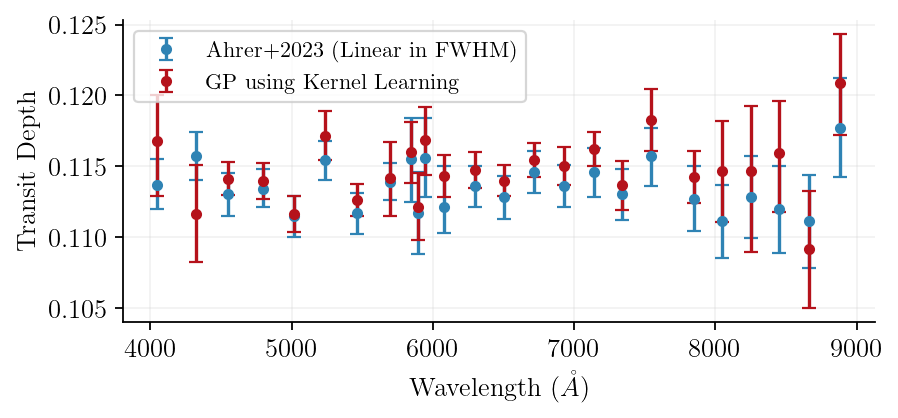

In [15]:
fig, ax = plt.subplots()

ax.errorbar(
    reference["wavelength"].iloc[1:],
    reference["Rp"][1:],
    yerr=reference[["e_Rp_lower", "e_Rp_upper"]][1:].T,
    fmt=".",
    capsize=3,
    label="Ahrer+2023 (Linear in FWHM)",
)
ax.errorbar(
    reference["wavelength"].iloc[1:],
    Rp_percentiles[0, 1:],
    yerr=errorbars[:, 1:],
    fmt=".",
    capsize=3,
    label="GP using Kernel Learning",
)

ax.legend()
ax.set_xlabel(r"Wavelength ($\mathring{A}$)")
ax.set_ylabel("Transit Depth")
fig.savefig("../figures/006_HATS46b/spectrum.pdf")

### LIGHT CURVES

In [16]:
rng_key, sample_key = jax.random.split(rng_key)

# get indices for random sample from mcmc chain
num_parameter_samples = 100
parameter_sample_indices = jax.random.choice(
    sample_key,
    np.array(chains["lc_parameter"])
    .reshape(num_datasets, -1, 2)
    .shape[1],  # flatten chains
    shape=(num_parameter_samples,),
)

In [17]:
samples_with_transit = {}
samples_without_transit = {}
means = {}
residuals = {}

for i in tqdm(range(num_datasets)):
    jax.clear_caches()

    # flatten chains
    lc_parameter = chains["lc_parameter"][i].reshape(
        -1, chains["lc_parameter"][i].shape[-1]
    )
    gp_parameter = chains["gp_parameter"][i].reshape(
        -1, chains["gp_parameter"][i].shape[-1]
    )

    fixed_parameter["u2"] = reference["u2"].iloc[i]
    transit = jit(partial(transit_model, fixed_parameter=fixed_parameter))

    def get_sample(idx, rng_key, num_samples=10):
        dist = predictive_distribution(
            gps[i],
            t,
            X=jnp.array(t[mask]),
            y=jnp.array(y[i][mask]),
            transit_model=transit,
            transit_parameter={
                parameter: lc_parameter[idx][j]
                for j, parameter in enumerate(["planet_radius", "u1"])
            },
            gp_parameter=gp_parameter[idx],
        )
        sample_with_transit = dist.sample(sample_shape=num_samples, seed=rng_key)
        sample_without_transit = sample_with_transit - transit(
            t,
            {
                parameter: lc_parameter[idx][i]
                for i, parameter in enumerate(["planet_radius", "u1"])
            },
        )
        mean = dist.mean()
        residuals = whitened_residuals(y[i], dist)
        return sample_with_transit, sample_without_transit, mean, residuals

    rng_key, *sample_keys = jax.random.split(rng_key, num_parameter_samples + 1)

    samples = Parallel(n_jobs=cores)(
        delayed(get_sample)(idx, key)
        for idx, key in zip(
            parameter_sample_indices,
            sample_keys,
        )
    )

    samples_with_transit[i] = np.array(
        [samples[j][0] for j in range(num_parameter_samples)]
    ).reshape(-1, len(y[i]))
    samples_without_transit[i] = np.array(
        [samples[j][1] for j in range(num_parameter_samples)]
    ).reshape(-1, len(y[i]))
    means[i] = np.array([samples[j][2] for j in range(num_parameter_samples)]).reshape(
        -1, len(y[i])
    )
    residuals[i] = np.array(
        [samples[j][3] for j in range(num_parameter_samples)]
    ).reshape(-1, len(y[i]))

residuals_std = [(residuals[i] ** 2).mean() for i in residuals.keys()]

  0%|          | 0/26 [00:00<?, ?it/s]

100%|██████████| 26/26 [17:28<00:00, 40.35s/it]


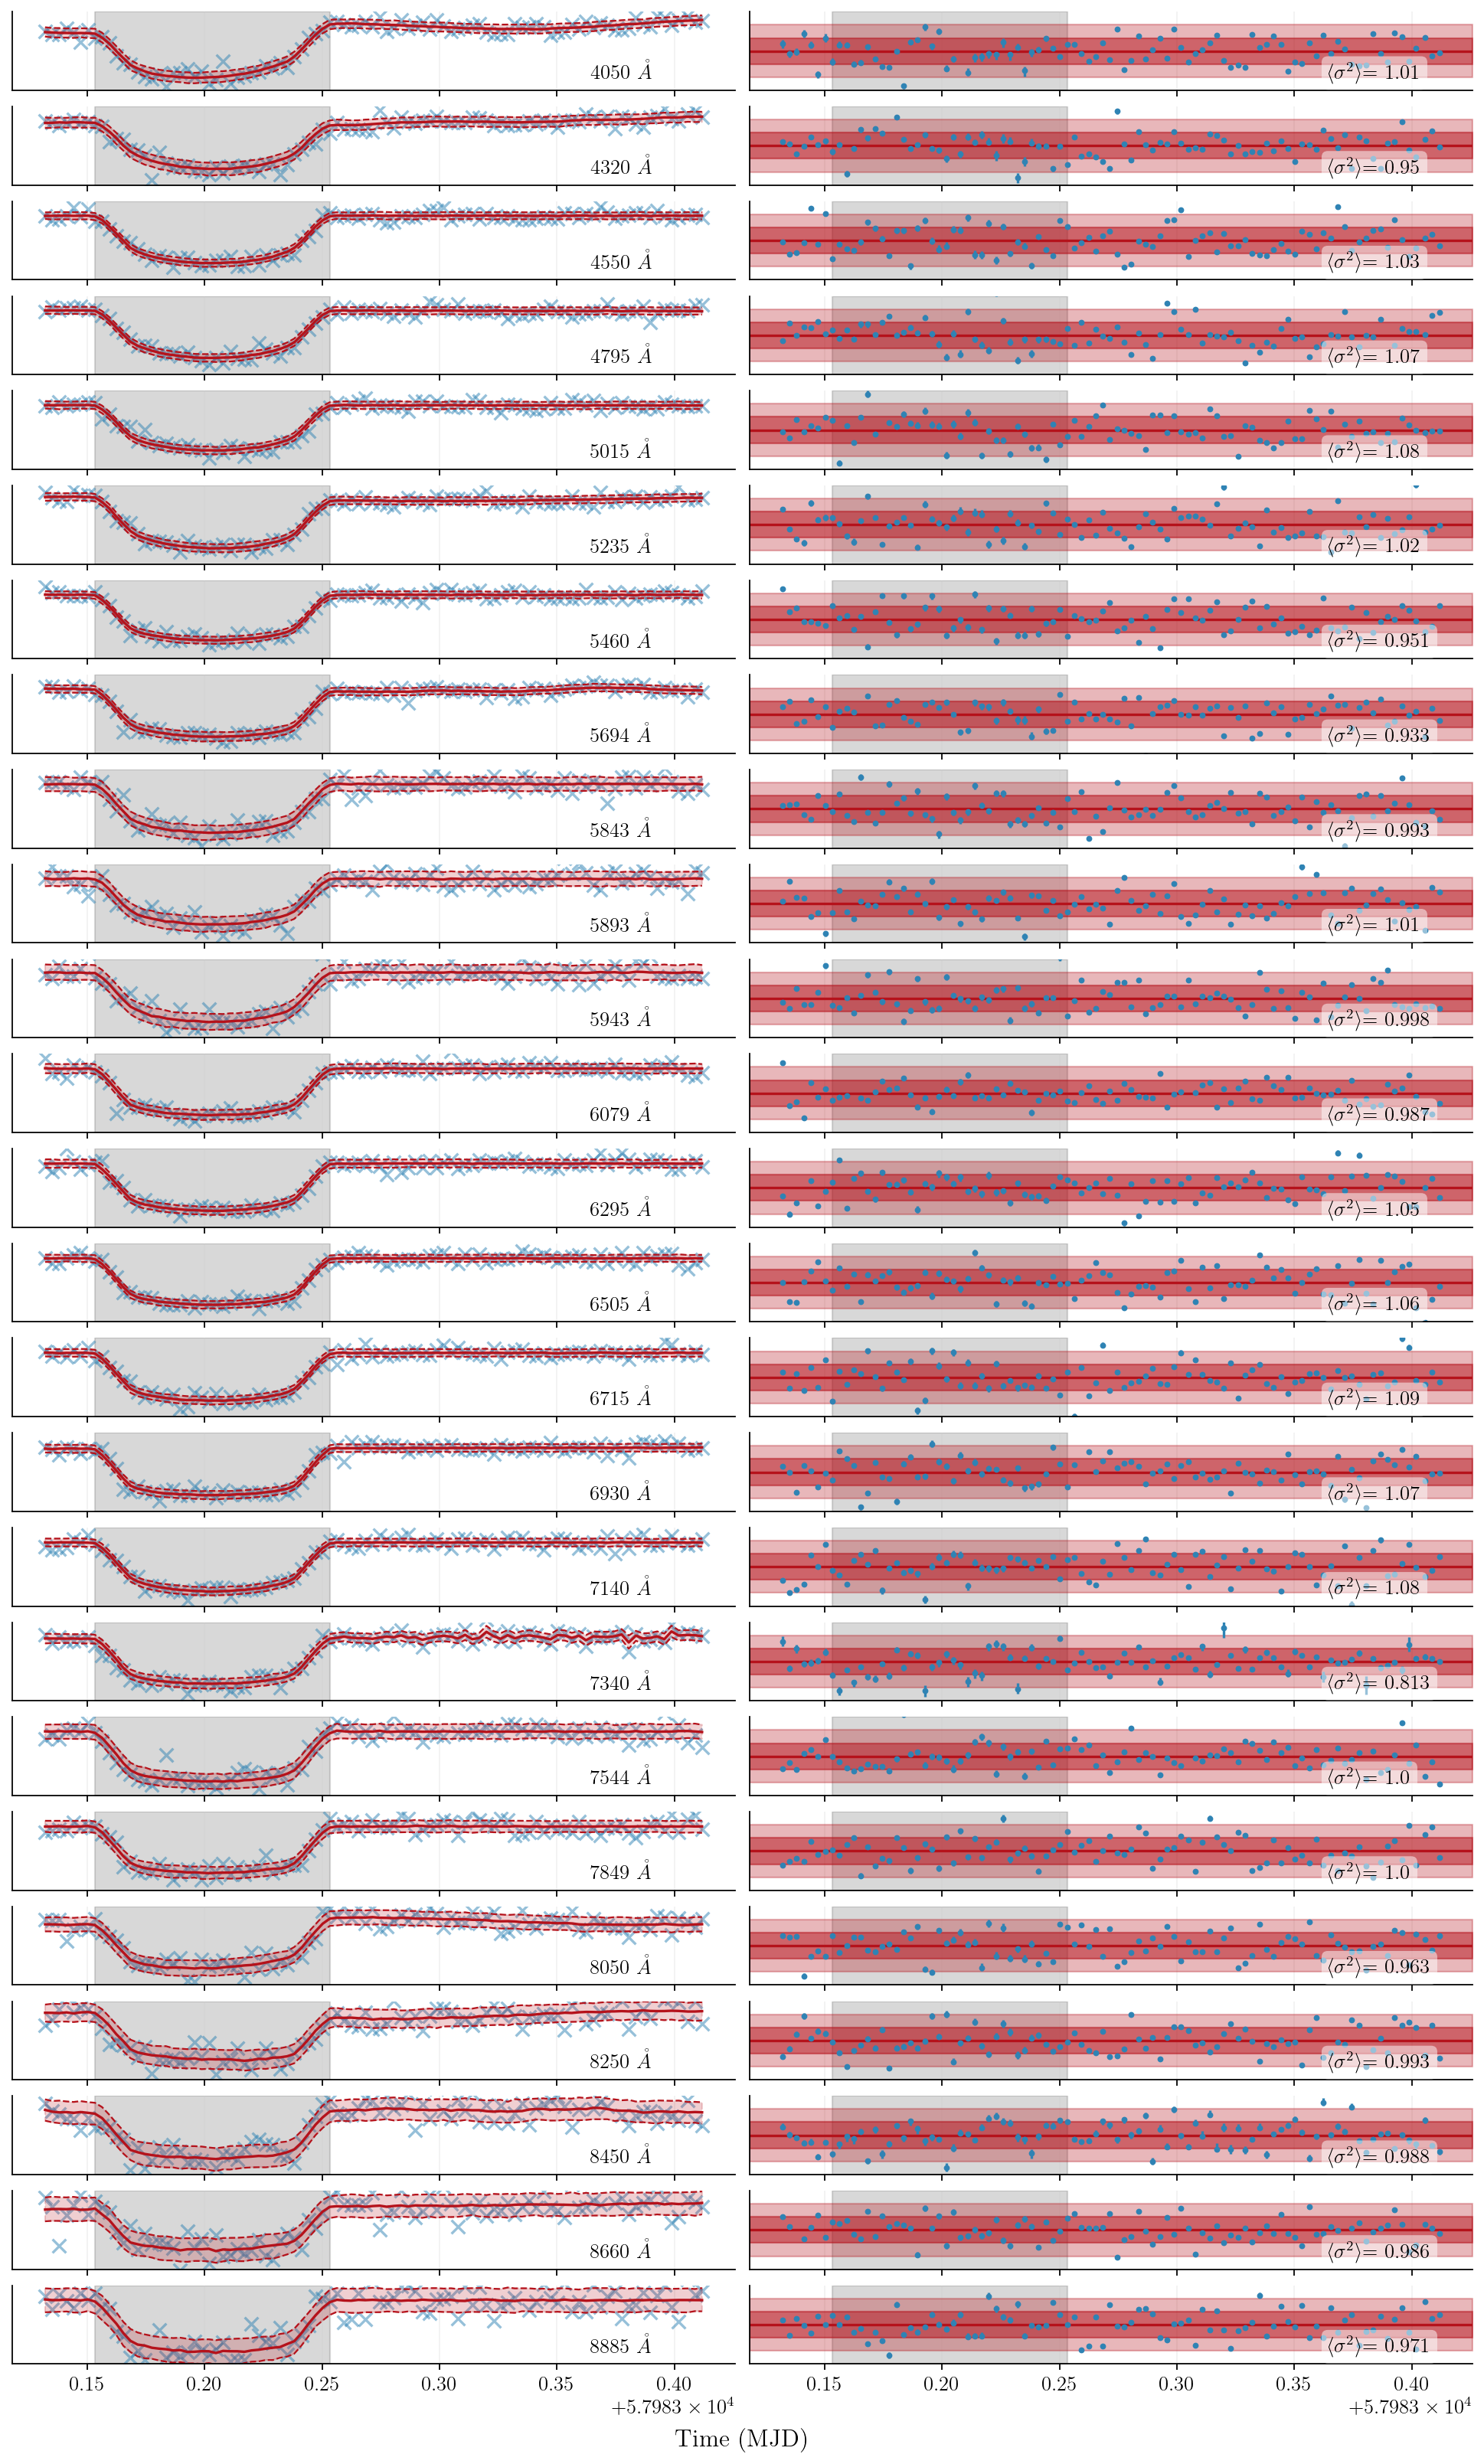

In [18]:
fig, ax = plt.subplots(
    num_datasets - 1,
    2,
    figsize=(12, 20),
    constrained_layout=False,
    sharex="col",
    sharey="col",
)
fig.subplots_adjust(hspace=0, wspace=0.01)

for i in range(1, num_datasets):
    i_ = i - 1
    t_ = t + t_min
    ax[i_, 0].scatter(
        t_,
        y[i],
        alpha=0.5,
    )
    plot_prediction(
        ax[i_, 0],
        t_,
        jnp.array(samples_with_transit[i]),
        errorbar=68,
    )
    # plot_prediction(
    #     ax[i_, 0],
    #     t_[~mask],
    #     jnp.array(samples_without_transit[i])[:, ~mask],
    #     kws_mean={"color": "grey", "alpha": 0.7},
    # )
    plot_residuals(
        ax[i_, 1],
        t_,
        jnp.array(residuals[i]),
        credible_region=68,
        kws_residuals={"markersize": 5},
    )
    ax[i_, 1].set_ylim(-3, 3)
    ax[i_, 1].yaxis.set_label_position("right")
    ax[i_, 1].yaxis.tick_right()
    for j in [0, 1]:
        plot_masks(ax[i_, j], t_, jnp.array(mask))
        ax[i_, j].set_yticks([])

    for j in range(2):
        if j == 0:
            text_str = str(reference["wavelength"].iloc[i]) + r" $\mathring{A}$"
        else:
            text_str = rf"$\langle \sigma^2 \rangle$= {residuals_std[i]:.3}"

        ax[i_, j].text(
            0.8,
            0.15,
            text_str,
            transform=ax[i_, j].transAxes,
            bbox={
                "boxstyle": "round",
                "facecolor": "white",
                "alpha": 0.5,
                "edgecolor": "none",
            },
        )

fig.supxlabel("Time (MJD)")
fig.savefig("../figures/006_HATS46b/light_curves_and_residuals.pdf")

### STATISTICS

In [193]:
rng_key, *sample_keys = jax.random.split(rng_key, 3)

statistics = []
for i in range(1, num_datasets):
    stddev_background = (residuals[i][:, mask] ** 2).mean()
    rho_background = np.array(rho_squared(residuals[i][:, mask], axis=1).mean())
    stddev_transit = (residuals[i][:, ~mask] ** 2).mean()
    rho_transit = np.array(rho_squared(residuals[i][:, ~mask], axis=1).mean())
    statistics.append(
        (
            reference["wavelength"].iloc[i],
            stddev_background,
            rho_background,
            stddev_transit,
            rho_transit,
        )
    )

statistics = pd.DataFrame(
    statistics,
    columns=[
        "wavelength",
        "sigma_background",
        "rho_background",
        "sigma_transit",
        "rho_transit",
    ],
).round(4)

print(
    f"Expected 95% Interval (Background, N={sum(mask)}): sigma =  {chi2_regions(sum(mask),1)[-2:].reshape(-1)}, rho = {rho_squared_region(sample_keys[0], sum(mask))}"
)
print(
    f"Expected 95% Interval (Transit, N={sum(~mask)}): {chi2_regions(sum(~mask),1)[-2:].reshape(-1)}"
)

rho_squared_credible_region(rng_key, residuals[1].shape[-1])
statistics

Expected 95% Interval (Background, N=59): [0.66971569 1.39544124]
Expected 95% Interval (Transit, N=34): [0.57717156 1.53712364]


,wavelength,sigma_background,rho_background,sigma_transit,rho_transit
0,4050,0.8333,1.4356988810931772,1.3094,0.834666685390137
1,4320,0.6692,1.3264923992378301,1.4363,1.0317831757329343
2,4550,0.9614,1.7129737523371846,1.1520,1.5142200981982974
3,4795,1.0417,1.9253100602666564,1.1240,2.6239721021720017
4,5015,0.6642,1.2351332060988736,1.8074,4.222984427943633
5,5235,1.0496,1.2444933612033109,0.9616,6.777966549679307
6,5460,0.8359,0.93500764547047,1.1497,2.9055376783468536
7,5694,0.7639,1.9901491661597057,1.2256,0.8064980040381602
8,5843,0.9307,1.1490935399332673,1.1017,4.251017988394911
9,5893,1.0833,1.1288418605640975,0.8877,0.7723700115082904


In [197]:
np.array(rho_squared(residuals[i][:, mask], axis=1).mean()).dtype

dtype('float64')

### ALLAN DEVIATION

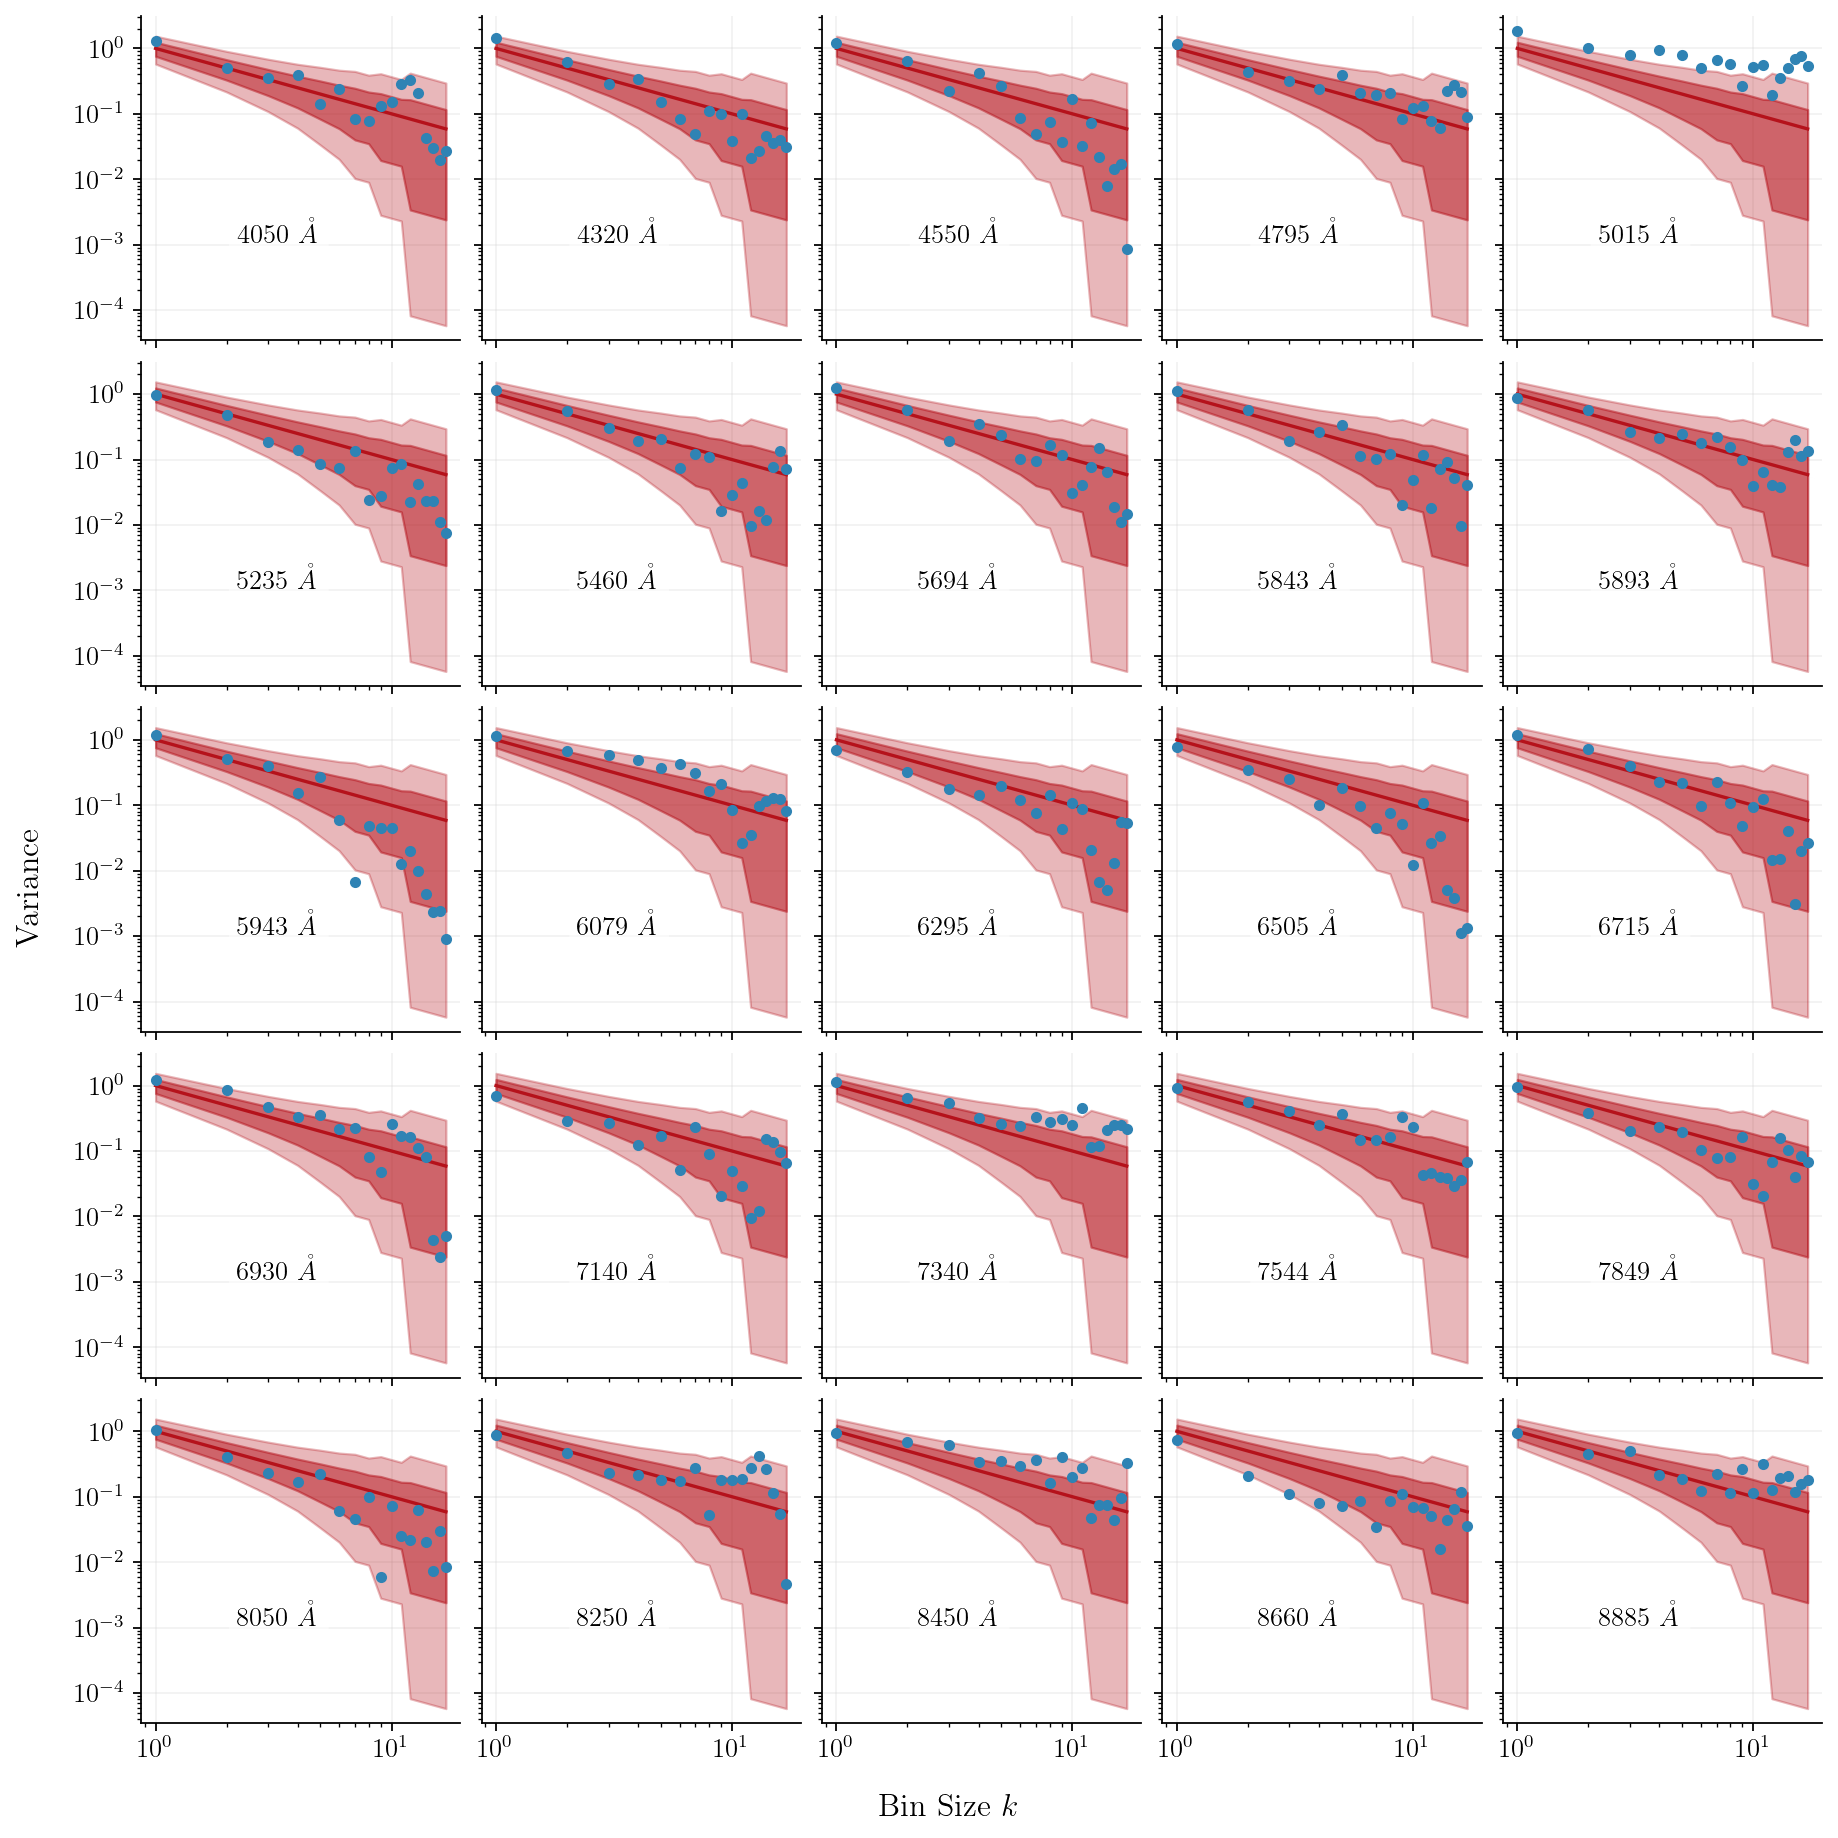

In [21]:
fig, axes = plt.subplots(
    5,
    5,
    figsize=(11, 11),
    sharex=True,
    sharey=True,
)

for i, ax in enumerate(axes.flatten(), start=1):
    plot_allan_deviation(ax, jnp.array(residuals[i][:, ~mask]))
    ax.text(
        0.3,
        0.3,
        str(reference["wavelength"].iloc[i]) + r" $\mathring{A}$",
        transform=ax.transAxes,
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "alpha": 0.5,
            "edgecolor": "none",
        },
    )

fig.supxlabel(r"Bin Size $k$", y=-0.03)
fig.supylabel("Variance", x=-0.03)
fig.savefig("../figures/006_HATS46b/allan_deviation.pdf")